In [1]:
from datasets import load_dataset

dataset = load_dataset("pierreguillou/DocLayNet-base")

c:\Users\lucas\anaconda3\envs\ai_cases\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\lucas\anaconda3\envs\ai_cases\lib\site-packages\datasets\load.py:1486: FutureWarning: The repository for pierreguillou/DocLayNet-base contains custom code which must be executed to correctly load the dataset. You can inspect the repository content at https://hf.co/datasets/pierreguillou/DocLayNet-base
You can avoid this message in future by passing the argument `trust_remote_code=True`.
Passing `trust_remote_code=True` will be mandatory to load this dataset from the next major release of `datasets`.
  warnings.warn(


In [2]:
dataset

DatasetDict({
    train: Dataset({
        features: ['id', 'texts', 'bboxes_block', 'bboxes_line', 'categories', 'image', 'page_hash', 'original_filename', 'page_no', 'num_pages', 'original_width', 'original_height', 'coco_width', 'coco_height', 'collection', 'doc_category'],
        num_rows: 6910
    })
    validation: Dataset({
        features: ['id', 'texts', 'bboxes_block', 'bboxes_line', 'categories', 'image', 'page_hash', 'original_filename', 'page_no', 'num_pages', 'original_width', 'original_height', 'coco_width', 'coco_height', 'collection', 'doc_category'],
        num_rows: 648
    })
    test: Dataset({
        features: ['id', 'texts', 'bboxes_block', 'bboxes_line', 'categories', 'image', 'page_hash', 'original_filename', 'page_no', 'num_pages', 'original_width', 'original_height', 'coco_width', 'coco_height', 'collection', 'doc_category'],
        num_rows: 499
    })
})

Classe: financial_reports


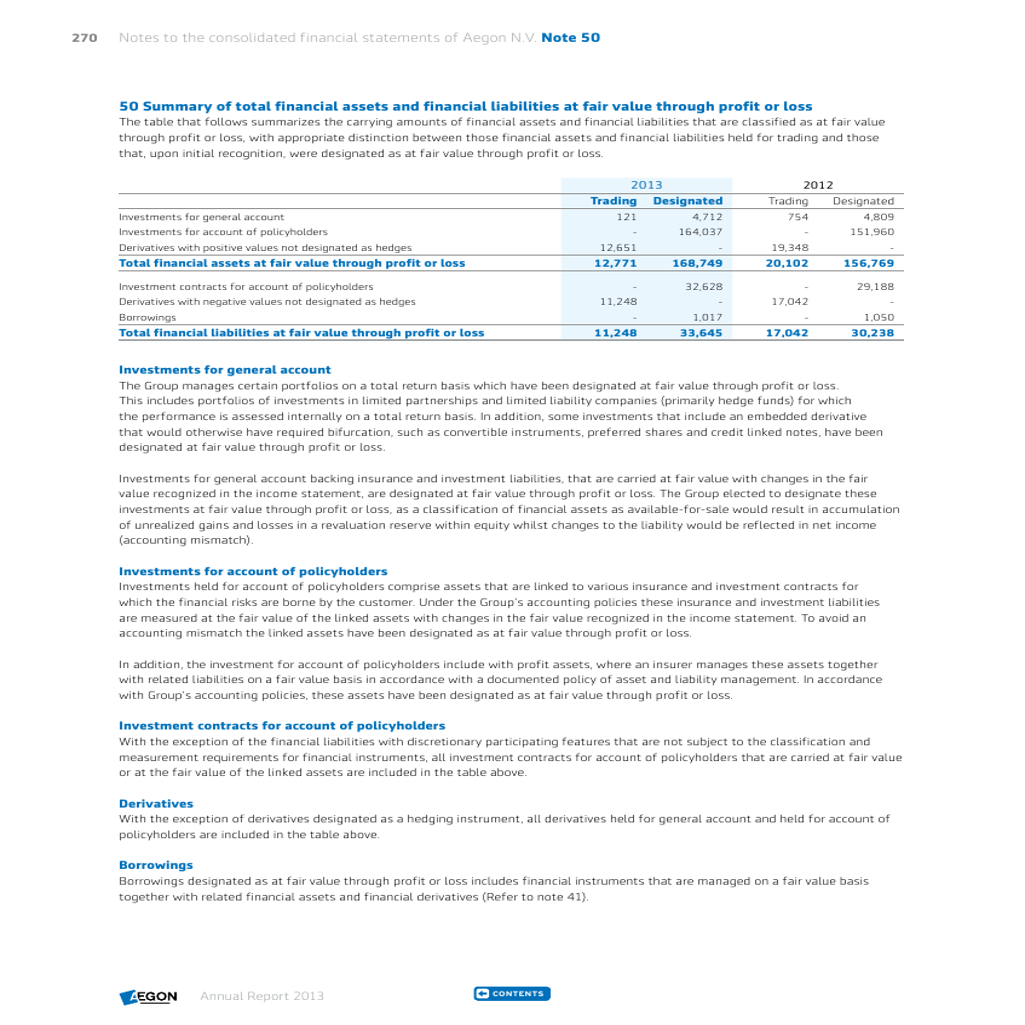

In [3]:
print(f"Classe: {dataset['train']['doc_category'][0]}")
dataset["train"]["image"][0]

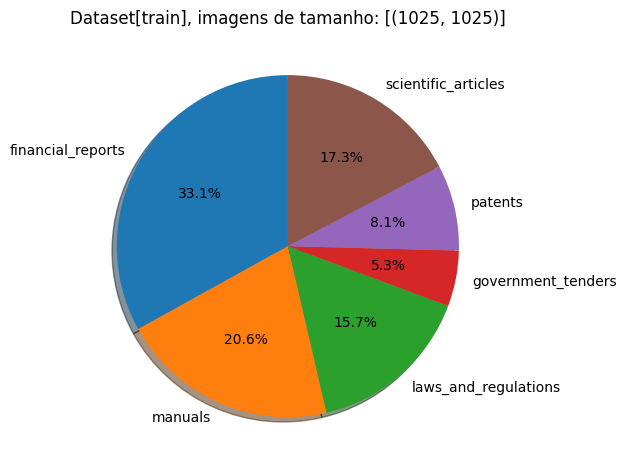

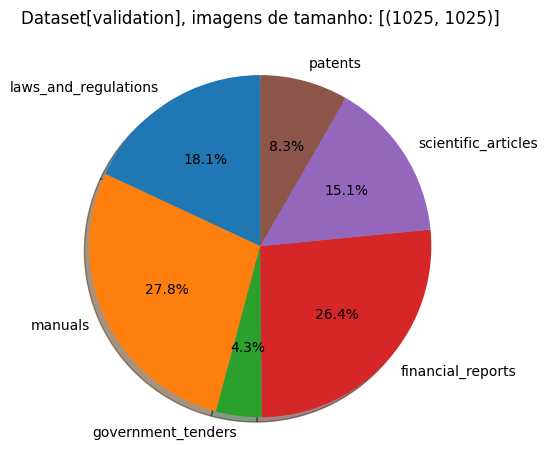

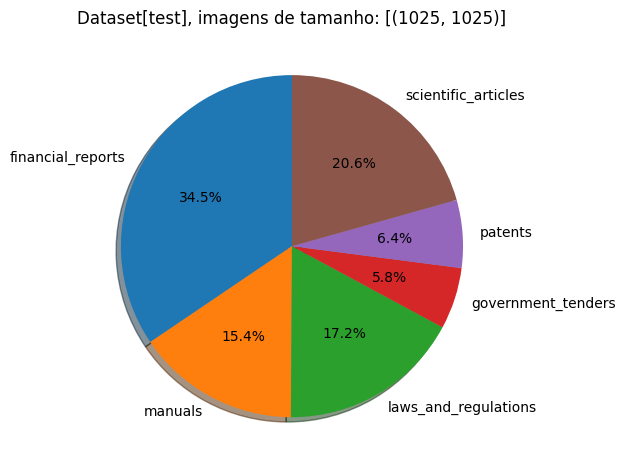

In [4]:
import matplotlib.pyplot as plt


for cat in dataset:
    
    categorias = dataset[cat]['doc_category']

    contagem_categorias = {}
    for categoria in categorias:
        if categoria in contagem_categorias:
            contagem_categorias[categoria] += 1
        else:
            contagem_categorias[categoria] = 1

    labels = contagem_categorias.keys()
    sizes = contagem_categorias.values()
    
    img_sizes = []
    for img in dataset[cat]["image"]:
        img_sizes.append(img.size)

    fig1, ax1 = plt.subplots()
    ax1.pie(sizes, labels=labels, autopct='%1.1f%%', shadow=True, startangle=90);
    ax1.set_title(f"Dataset[{cat}], imagens de tamanho: {list(set(img_sizes))}")
    plt.tight_layout()

In [5]:
for cat in dataset:
    categorias = dataset[cat]['doc_category']

    freq = {}
    for categoria in categorias:
        if categoria in freq:
            freq[categoria] += 1
        else:
            freq[categoria] = 1

    total_documentos = len(categorias)
    pesos = {categoria: total_documentos / frequencia for categoria, frequencia in freq.items()}
    print(pesos)

{'financial_reports': 3.0253940455341506, 'manuals': 4.859353023909986, 'laws_and_regulations': 6.374538745387454, 'government_tenders': 18.983516483516482, 'patents': 12.31729055258467, 'scientific_articles': 5.7824267782426775}
{'laws_and_regulations': 5.538461538461538, 'manuals': 3.6, 'government_tenders': 23.142857142857142, 'financial_reports': 3.789473684210526, 'scientific_articles': 6.612244897959184, 'patents': 12.0}
{'financial_reports': 2.9011627906976742, 'manuals': 6.48051948051948, 'laws_and_regulations': 5.8023255813953485, 'government_tenders': 17.20689655172414, 'patents': 15.59375, 'scientific_articles': 4.844660194174757}


In [6]:
label_names = []
for label in dataset["validation"]['doc_category']:
    label_names.append(label)

label_names = list(set(label_names))

In [7]:
label_names

['manuals',
 'patents',
 'scientific_articles',
 'government_tenders',
 'financial_reports',
 'laws_and_regulations']

In [8]:
new_ds = dataset.remove_columns([col for col in dataset['validation'].column_names if col not in ['image', 'doc_category']])
new_ds

DatasetDict({
    train: Dataset({
        features: ['image', 'doc_category'],
        num_rows: 6910
    })
    validation: Dataset({
        features: ['image', 'doc_category'],
        num_rows: 648
    })
    test: Dataset({
        features: ['image', 'doc_category'],
        num_rows: 499
    })
})

In [9]:
prep_ds = new_ds.class_encode_column("doc_category")

In [10]:
train_ds, val_ds, test_ds = prep_ds["train"], prep_ds["validation"], prep_ds["test"]
train_ds

Dataset({
    features: ['image', 'doc_category'],
    num_rows: 6910
})

In [11]:
id2label = {id:label for id, label in enumerate(train_ds.features['doc_category'].names)}
label2id = {label:id for id,label in id2label.items()}
id2label

{0: 'financial_reports',
 1: 'government_tenders',
 2: 'laws_and_regulations',
 3: 'manuals',
 4: 'patents',
 5: 'scientific_articles'}

In [12]:
from transformers import AutoImageProcessor
from torchvision.transforms import v2

processor = AutoImageProcessor.from_pretrained("facebook/levit-128S")


image_mean, image_std = processor.image_mean, processor.image_std
size = processor.size

normalize = v2.Normalize(mean=image_mean, std=image_std)


In [13]:
image_mean, image_std, size, normalize

([0.485, 0.456, 0.406],
 [0.229, 0.224, 0.225],
 {'shortest_edge': 224},
 Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225], inplace=False))

In [14]:
image_test = processor(train_ds[0]["image"], return_tensors="pt")
image_test["pixel_values"].shape

torch.Size([1, 3, 224, 224])

In [15]:
from collections import Counter

labels_train = Counter(train_ds['doc_category'])
total_train = sum(labels_train.values())
# Para cada par (categoria, contagem) retornado por labels_train.items(),
# a expressão count / total_train calcula a fração da contagem daquela categoria em relação ao total de documentos.
label_probs_train = {label: count / total_train for label, count in labels_train.items()}
# Em label_probs_train, cada chave é uma categoria e cada valor é a probabilidade associada a essa categoria.

In [16]:
label_probs_train

{0: 0.3305354558610709,
 3: 0.20578871201157742,
 2: 0.1568740955137482,
 1: 0.05267727930535456,
 4: 0.08118668596237337,
 5: 0.17293777134587554}

In [17]:
# Calculo da probabilidade complementar de cada categoria
list(label_probs_train.values())
w_labels = []
for label in list(label_probs_train.values()):
    w_labels.append(1 - label)

In [18]:
w_labels

[0.6694645441389291,
 0.7942112879884226,
 0.8431259044862518,
 0.9473227206946454,
 0.9188133140376267,
 0.8270622286541245]

In [19]:
train_transforms = v2.Compose([
        v2.Resize((224, 224)),
        v2.RandomHorizontalFlip(0.4),
        v2.RandomVerticalFlip(0.1),
        v2.RandomApply(transforms=[v2.RandomRotation(degrees=(0, 90))], p=0.5),
        v2.RandomApply(transforms=[v2.ColorJitter(brightness=.3, hue=.1)], p=0.3),
        v2.RandomApply(transforms=[v2.GaussianBlur(kernel_size=(5, 9))], p=0.3),
        v2.ToTensor(),
        normalize
    ])

def train_transform(examples):
    examples['pixel_values'] = [train_transforms(image.convert("RGB")) for image in examples['image']]
    return examples

# aplicar a transformacao nas categorias minoritarias
train_ds.set_transform(train_transform)
val_ds.set_transform(train_transform)

c:\Users\lucas\anaconda3\envs\ai_cases\lib\site-packages\torchvision\transforms\v2\_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(


In [20]:
test_transform = v2.Compose([
    v2.Resize((224, 224)),
    v2.ToTensor(),
    normalize
])

def test_transforms(examples):
    examples['pixel_values'] = [test_transform(image.convert("RGB")) for image in examples['image']]
    return examples

test_ds.set_transform(test_transforms)

In [21]:
from transformers import LevitForImageClassification
model = LevitForImageClassification.from_pretrained('facebook/levit-128S',
                                                  id2label=id2label,
                                                  label2id=label2id,
                                                  ignore_mismatched_sizes=True)
processor = AutoImageProcessor.from_pretrained('facebook/levit-128S', do_rescale = False, return_tensors = 'pt')

Some weights of LevitForImageClassification were not initialized from the model checkpoint at facebook/levit-128S and are newly initialized because the shapes did not match:
- classifier.linear.bias: found shape torch.Size([1000]) in the checkpoint and torch.Size([6]) in the model instantiated
- classifier.linear.weight: found shape torch.Size([1000, 384]) in the checkpoint and torch.Size([6, 384]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [22]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import numpy as np

def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    predictions = np.argmax(predictions, axis=1)
    
    accuracy = accuracy_score(labels, predictions)
    precision = precision_score(labels, predictions, average='weighted')
    recall = recall_score(labels, predictions, average='weighted')
    f1 = f1_score(labels, predictions, average='weighted')

    return {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1
    }

In [23]:
import torch

def collate_fn(examples):
    pixel_values = torch.stack([example["pixel_values"] for example in examples])
    labels = torch.tensor([example["doc_category"] for example in examples])
    return {"pixel_values": pixel_values, "labels": labels}

In [24]:
!nvidia-smi

Wed May 22 18:58:42 2024       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 555.85                 Driver Version: 555.85         CUDA Version: 12.5     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                  Driver-Model | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 3060 ...  WDDM  |   00000000:01:00.0  On |                  N/A |
| N/A   67C    P5             22W /  124W |    1828MiB /   6144MiB |      5%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [25]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [26]:
model.to(device)

LevitForImageClassification(
  (levit): LevitModel(
    (patch_embeddings): LevitPatchEmbeddings(
      (embedding_layer_1): LevitConvEmbeddings(
        (convolution): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (batch_norm): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (activation_layer_1): Hardswish()
      (embedding_layer_2): LevitConvEmbeddings(
        (convolution): Conv2d(16, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (batch_norm): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (activation_layer_2): Hardswish()
      (embedding_layer_3): LevitConvEmbeddings(
        (convolution): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (batch_norm): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (activation_layer_3): Hardswish()
      

In [27]:
from accelerate import Accelerator

accelerator = Accelerator()

In [28]:
from transformers import TrainingArguments, Trainer

args = TrainingArguments(
    f"doclaynet-classification_v2",
    evaluation_strategy="epoch",
    save_strategy="epoch",
    learning_rate=4e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=1,
    num_train_epochs=15,
    weight_decay=0.05,
    save_total_limit=1,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    remove_unused_columns=False,
)

c:\Users\lucas\anaconda3\envs\ai_cases\lib\site-packages\transformers\training_args.py:1474: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(


In [29]:
args.device

device(type='cuda', index=0)

In [30]:
w_labels_tensor = torch.tensor(w_labels).float()
w_labels_tensor = w_labels_tensor.to(device)

In [31]:
# class CustomTrainer(Trainer):
#     def compute_loss(self, model, inputs, return_outputs=False):
#         labels = inputs.get("labels")
#         outputs = model(**inputs)
#         logits = outputs.get('logits')
#         loss_fct = torch.nn.CrossEntropyLoss(weight=w_labels_tensor)
#         loss = loss_fct(logits.view(-1, self.model.config.num_labels), labels.view(-1))
#         return (loss, outputs) if return_outputs else loss

In [32]:
trainer = Trainer(
    model,
    # passar uma seed
    args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    data_collator=collate_fn,
    compute_metrics=compute_metrics,
    tokenizer=processor,
)

In [33]:
trainer.train()

                                                  
  7%|▋         | 432/6480 [03:04<36:05,  2.79it/s]

{'eval_loss': 1.7666946649551392, 'eval_accuracy': 0.2762345679012346, 'eval_precision': 0.3777491171902914, 'eval_recall': 0.2762345679012346, 'eval_f1': 0.2578179740760417, 'eval_runtime': 28.9511, 'eval_samples_per_second': 22.383, 'eval_steps_per_second': 22.383, 'epoch': 1.0}


  8%|▊         | 500/6480 [03:29<36:17,  2.75it/s]   

{'loss': 1.7247, 'grad_norm': 533.9619140625, 'learning_rate': 3.6913580246913584e-05, 'epoch': 1.16}


                                                  
 13%|█▎        | 864/6480 [06:13<34:46,  2.69it/s]

...

                                                   
100%|██████████| 6480/6480 [46:51<00:00,  2.80it/s]

{'eval_loss': 0.9927663803100586, 'eval_accuracy': 0.6898148148148148, 'eval_precision': 0.6820311432246252, 'eval_recall': 0.6898148148148148, 'eval_f1': 0.6769919308297937, 'eval_runtime': 30.1521, 'eval_samples_per_second': 21.491, 'eval_steps_per_second': 21.491, 'epoch': 15.0}


100%|██████████| 6480/6480 [46:52<00:00,  2.30it/s]

{'train_runtime': 2812.0806, 'train_samples_per_second': 36.859, 'train_steps_per_second': 2.304, 'train_loss': 1.0856837237322772, 'epoch': 15.0}


TrainOutput(global_step=6480, training_loss=1.0856837237322772, metrics={'train_runtime': 2812.0806, 'train_samples_per_second': 36.859, 'train_steps_per_second': 2.304, 'total_flos': 6.5609861732352e+17, 'train_loss': 1.0856837237322772, 'epoch': 15.0})

In [34]:
metrics = trainer.predict(test_ds)

100%|██████████| 499/499 [00:20<00:00, 23.77it/s]


In [35]:
metrics.metrics

{'test_loss': 0.9440068006515503,
 'test_accuracy': 0.751503006012024,
 'test_precision': 0.73384440621752,
 'test_recall': 0.751503006012024,
 'test_f1': 0.7372073002514373,
 'test_runtime': 21.0828,
 'test_samples_per_second': 23.669,
 'test_steps_per_second': 23.669}

In [42]:
torch.sigmoid(torch.tensor(metrics[0]))

tensor([[0.9503, 0.3307, 0.5252, 0.1975, 0.3761, 0.3071],
        [0.8931, 0.3423, 0.7698, 0.2455, 0.3324, 0.2242],
        [0.3472, 0.4573, 0.5620, 0.6713, 0.4732, 0.4972],
        ...,
        [0.0288, 0.6313, 0.6368, 0.2957, 0.8260, 0.9312],
        [0.0620, 0.4614, 0.7334, 0.5370, 0.9310, 0.6250],
        [0.2477, 0.4738, 0.5151, 0.5828, 0.7170, 0.5148]])

In [68]:
categories = []
for category in test_ds:
    categories.append(category["doc_category"])

In [84]:
torch.argmax(torch.sigmoid(torch.tensor(metrics.predictions)))

tensor(3)

In [86]:
import pandas as pd
df_predictions = pd.DataFrame(torch.sigmoid(torch.tensor(metrics.predictions)), columns=list(label2id.keys()))
df_predictions['Predicted Label'] = torch.argmax(torch.sigmoid(torch.tensor(metrics.predictions)), dim=1).numpy()
df_predictions['Predicted Category'] = df_predictions['Predicted Label'].map(id2label)
df_predictions['True Label'] = categories

df_predictions

,financial_reports,government_tenders,laws_and_regulations,manuals,patents,scientific_articles,Predicted Label,Predicted Category,True Label
0,0.950314,0.330660,0.525172,0.197508,0.376131,0.307105,0,financial_reports,0
1,0.893137,0.342287,0.769788,0.245532,0.332441,0.224182,0,financial_reports,0
2,0.347229,0.457293,0.561985,0.671313,0.473163,0.497207,3,manuals,3
3,0.903793,0.375586,0.425779,0.249973,0.323338,0.418724,0,financial_reports,0
4,0.830665,0.454910,0.486462,0.528973,0.422939,0.182500,0,financial_reports,0
...,...,...,...,...,...,...,...,...,...
494,0.196105,0.432661,0.815168,0.437206,0.709437,0.458316,2,laws_and_regulations,2
495,0.985077,0.269682,0.124427,0.237767,0.358409,0.379732,0,financial_reports,0
496,0.028819,0.631316,0.636769,0.295747,0.826030,0.931199,5,scientific_articles,5
497,0.062034,0.461389,0.733409,0.537020,0.930985,0.625044,4,patents,2


In [87]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix


In [88]:
df_predictions['True Category'] = df_predictions['True Label'].map(id2label)

In [89]:
df_predictions

,financial_reports,government_tenders,laws_and_regulations,manuals,patents,scientific_articles,Predicted Label,Predicted Category,True Label,True Category
0,0.950314,0.330660,0.525172,0.197508,0.376131,0.307105,0,financial_reports,0,financial_reports
1,0.893137,0.342287,0.769788,0.245532,0.332441,0.224182,0,financial_reports,0,financial_reports
2,0.347229,0.457293,0.561985,0.671313,0.473163,0.497207,3,manuals,3,manuals
3,0.903793,0.375586,0.425779,0.249973,0.323338,0.418724,0,financial_reports,0,financial_reports
4,0.830665,0.454910,0.486462,0.528973,0.422939,0.182500,0,financial_reports,0,financial_reports
...,...,...,...,...,...,...,...,...,...,...
494,0.196105,0.432661,0.815168,0.437206,0.709437,0.458316,2,laws_and_regulations,2,laws_and_regulations
495,0.985077,0.269682,0.124427,0.237767,0.358409,0.379732,0,financial_reports,0,financial_reports
496,0.028819,0.631316,0.636769,0.295747,0.826030,0.931199,5,scientific_articles,5,scientific_articles
497,0.062034,0.461389,0.733409,0.537020,0.930985,0.625044,4,patents,2,laws_and_regulations


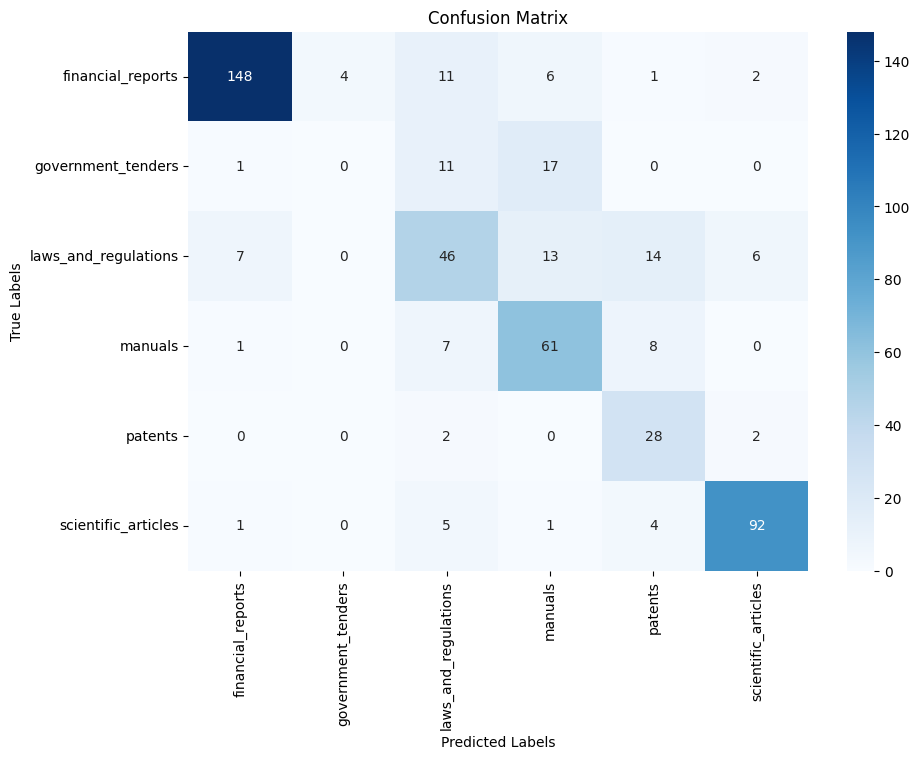

In [90]:
cm = confusion_matrix(df_predictions['True Category'], df_predictions['Predicted Category'], labels=list(id2label.values()))

plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt="d", cmap='Blues', xticklabels=id2label.values(), yticklabels=id2label.values())
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()
